# The Relative Rotation Graph — a quantitative teardown 🔬
### The RS-Ratio/RS-Momentum construction · the matched-random control · a cost sweep · sub-period stability · the quadrant transition-matrix myth-check · a 20-seed synthetic null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Rotates_clockwise%3F: Confirmed](https://img.shields.io/badge/Rotates_clockwise%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The RRG (de Kempenaer, RRG Research) is a practitioner charting technique, not a published factor model — so the job here is to (1) build the two axes ourselves, explicitly, (2) test whether the descriptive rotation story holds, and (3) test whether the trading rule it implies ("buy Leading") beats the honest controls, chiefly a **matched-random** control that isolates *selection* skill from the mechanical cash-timing effect of a quadrant-conditioned rule.

> ⚠️ **Data note.** 11 SPDR sector ETFs + SPY, daily adjusted closes, yfinance, cached, 1998-12-01 → 2026-06-30 (XLRE from 2015-10, XLC from 2018-06 — named). No survivorship (all tickers used through their own live history). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `27323464af92`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from relative_rotation_graph import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    FRAMES = st.rrg_frame(PRICES, data.TICKERS, data.BENCHMARK, data.RS_WINDOW, data.MOM_WINDOW)
    QUAD = st.monthly_quadrants(FRAMES)
    RETS = st.monthly_returns(PRICES, data.TICKERS)
else:
    PRICES = FRAMES = QUAD = RETS = None
print("real cache present:", HAVE_REAL, "| quadrant months:", (0 if QUAD is None else len(QUAD)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1998-12-01', 'end': '2026-06-30', 'fp': '27323464af92', 'n_rows': 6936, 'n_months_quad': 324, 'quad_lo': '1999-07', 'quad_hi': '2026-06', 'n_months_ret': 331, 'ret_lo': '1998-12', 'ret_hi': '2026-06', 'rs_window': 63, 'mom_window': 21, 'cost_bps': 5.0, 'rrg': {'ann': 6.66, 'vol': 16.49, 'sharpe': 0.404, 'dd': -46.21, 't': 2.36, 'n': 331}, 'ew': {'ann': 9.64, 'vol': 14.6, 'sharpe': 0.66, 'dd': -49.12, 't': 3.55, 'n': 330}, 'spy': {'ann': 9.46, 'vol': 15.11, 'sharpe': 0.626, 'dd': -50.78, 't': 3.25, 'n': 330}, 'mom': {'ann': 8.45, 'vol': 13.66, 'sharpe': 0.619, 'dd': -32.45, 't': 3.36, 'n': 331}, 'n_leading_dist': {0: 26, 1: 54, 2: 77, 3: 88, 4: 55, 5: 22, 6: 6, 7: 2, 8: 1}, 'mean_n_leading': 2.6, 'cash_months': 26, 'cash_pct': 7.9, 'mean_turnover': 76.9, 'act_ew': {'ann': -2.96, 't': -2.07, 'n': 330}, 'act_spy': {'ann': -2.78, 't': -1.68, 'n': 330}, 'act_mom': {'ann': -1.8, 't': -0.93, 'n': 331}, 'act_rand': {'ann': -0.5, 't': -0.35, 'n': 331}, 'cost_sweep': {0.0: (7.58, 0.46, 2.69), 5.0: (6.66, 0.404, 2.36), 10.0: (5.74, 0.348, 2.03), 20.0: (3.89, 0.236, 1.38)}, 'sub_periods': {'1999-2009': {'rrg_ann': 3.81, 'rrg_sharpe': 0.218, 'rrg_t': 0.72, 'rrg_n': 126, 'ew_ann': 3.77, 'ew_sharpe': 0.242, 'ew_t': 0.68}, '2010-2019': {'rrg_ann': 8.82, 'rrg_sharpe': 0.711, 'rrg_t': 2.58, 'rrg_n': 120, 'ew_ann': 12.51, 'ew_sharpe': 1.044, 'ew_t': 4.3}, '2020-2026': {'rrg_ann': 8.52, 'rrg_sharpe': 0.412, 'rrg_t': 1.21, 'rrg_n': 78, 'ew_ann': 13.32, 'ew_sharpe': 0.808, 'ew_t': 2.65}}, 'trans': {'Leading': {'Leading': 196, 'Weakening': 409, 'Lagging': 237, 'Improving': 15}, 'Weakening': {'Leading': 173, 'Weakening': 251, 'Lagging': 247, 'Improving': 9}, 'Lagging': {'Leading': 219, 'Weakening': 6, 'Lagging': 177, 'Improving': 430}, 'Improving': {'Leading': 269, 'Weakening': 14, 'Lagging': 167, 'Improving': 298}}, 'clockwise_pct': 61.7, 'random_baseline_pct': 33.3, 'n_moves': 2195, 'per_quad_cw': {'Leading': 61.9, 'Weakening': 57.6, 'Lagging': 65.6, 'Improving': 59.8}, 'syn_null_mean': -0.3, 'syn_null_sd': 1.11, 'syn_null_fire': 1, 'syn_null_seeds': 20, 'syn_planted_ann': 15.3, 'syn_planted_t': 6.2}


real cache present: True | quadrant months: 324


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | vs matched-random control: **t = -0.35** (-0.50%/yr); vs plain 6-1 momentum: t = -0.93 (-1.80%/yr); vs equal-weight: **t = -2.07** (-2.96%/yr, certified negative) |
| **Tradability** | `MIRAGE` | 77% one-way monthly turnover; Sharpe 0.404 vs EW 0.660 / SPY 0.626 / MOM 0.619; certified shortfall vs EW in 2010s and 2020s |
| **Rotates clockwise?** | `CONFIRMED` | 61.7% of quadrant changes go clockwise-forward vs a 33.3% random baseline (2,195 changes) |

> 💡 In plain words: the chart's descriptive mechanics check out; the trading rule built on top of them does not.

## 1 · The claim, steelmanned

Let $P_{i,t}$ be sector $i$'s price and $B_t$ SPY's. Define the relative-strength line $RS_{i,t} = P_{i,t}/B_t$. The RRG's own construction (vendors don't publish exact constants, so we define ours in the open):

$$\text{RS-Ratio}_{i,t} = 100 + \frac{RS_{i,t} - \overline{RS_i}_{[t-W,t]}}{\sigma(RS_i)_{[t-W,t]}}, \quad \text{RS-Momentum}_{i,t} = 100 + \frac{\Delta_M \text{RS-Ratio}_{i,t} - \overline{\Delta_M \text{RS-Ratio}_i}_{[t-W,t]}}{\sigma(\Delta_M \text{RS-Ratio}_i)_{[t-W,t]}}$$

with $W$ = 63 trading days, $M$ = 21 trading days. Four quadrants from the sign of (RS-Ratio − 100, RS-Momentum − 100); the claim:

- **H₁ (rotation).** Sectors move through the quadrants in the claimed clockwise order (Leading → Weakening → Lagging → Improving) more than a random mover would.
- **H₂ (selection).** Holding the Leading quadrant beats a same-size random pick — i.e. the quadrant *label* carries forward-looking information about returns.
- **H₃ (dominance).** The two-axis read beats the one-axis (plain momentum) control it's explicitly sold as improving on.

We find **H₁ supported** (62% vs 33% baseline), **H₂ rejected** (*t* = -0.35), **H₃ rejected** (negative point estimate, *t* = -0.93).

## 2 · So what? — inference design

The confound that sinks a naive test here is **mechanical**: a rule that goes to cash whenever nothing is Leading will, on a positive-drift tape, underperform a *fully invested* benchmark (equal-weight, SPY) for reasons that have nothing to do with stock-picking skill — it's simply out of the market some months. So the decisive test is not RRG vs equal-weight (that conflates cash-timing with selection) — it's RRG vs a **matched-random control**: each month, pick the same *number* of random sectors RRG actually held (0 → cash, exactly matching RRG's cash months), Monte-Carlo-averaged over 200 seeds so no single lucky draw decides it. Any active return left over is purely about *which* sectors, not *how many*.

## 3 · How we'd know — the protocol

- **Universe.** 11 SPDR sector ETFs vs SPY, 1998-12-01 → 2026-06-30 daily, resampled to month-end for the rebalance.
- **Signal.** RS-Ratio (W=63d) x RS-Momentum (M=21d), both rolling z-scores centred on 100.
- **Execution.** One lag: quadrant read at month-end close *t*, position (equal-weight the Leading quadrant, cash if empty) held over month *t+1*.
- **Controls.** SPY, equal-weight basket, plain 6-1 top-3 momentum (sibling 225's exact construction), matched-random (200-seed Monte Carlo).
- **Costs.** One-way bps x NAV per leg on realised turnover, swept 0/5/10/20 bps; round trip = 2x.
- **Myth-check.** Pooled quadrant transition matrix across all 11 tickers; clockwise share of quadrant *changes* vs the 33.3% baseline three alternatives would give a uniform random mover.
- **Control.** Synthetic daily multi-sector panel, AR(1) planted relative-drift knob; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The headline race

RRG's Leading-quadrant rotation vs three controls, net of 5bps one-way cost.

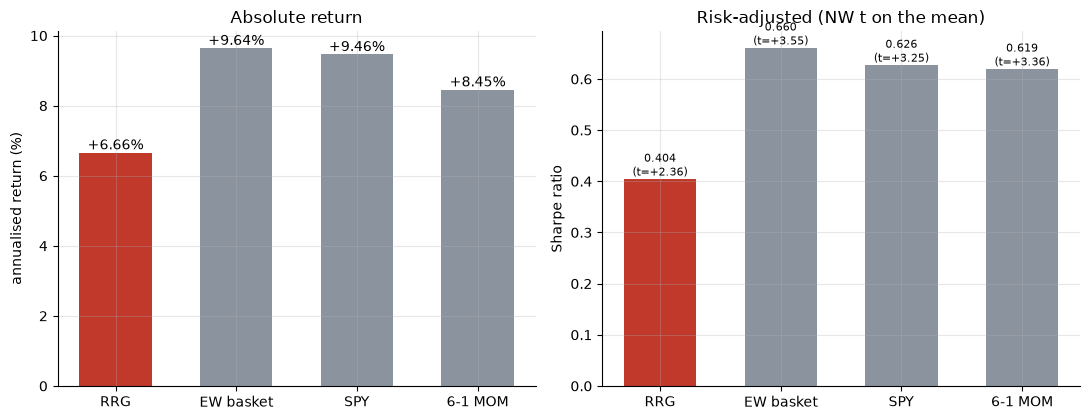

{'RRG': 6.66, 'EW basket': 9.64, 'SPY': 9.46, '6-1 MOM': 8.45} {'RRG': 0.404, 'EW basket': 0.66, 'SPY': 0.626, '6-1 MOM': 0.619}


In [2]:
if HAVE_REAL:
    rrg = st.run_rrg_strategy(QUAD, RETS, cost_bps=R['cost_bps'])
    ew = st.equal_weight_returns(RETS)
    spy_m = st.benchmark_monthly_returns(PRICES, data.BENCHMARK)
    mom = st.run_momentum_strategy(RETS, lookback=6, skip=1, k=3, cost_bps=R['cost_bps'])
    rows = {'RRG': st.summarize(rrg['r_net']), 'EW': st.summarize(ew),
            'SPY': st.summarize(spy_m), 'MOM': st.summarize(mom['r_net'])}
    anns = [rows[k]['ann_ret']*100 for k in ['RRG','EW','SPY','MOM']]
    sharpes = [rows[k]['sharpe'] for k in ['RRG','EW','SPY','MOM']]
    ts = [rows[k]['tstat'] for k in ['RRG','EW','SPY','MOM']]
else:
    anns = [R['rrg']['ann'], R['ew']['ann'], R['spy']['ann'], R['mom']['ann']]
    sharpes = [R['rrg']['sharpe'], R['ew']['sharpe'], R['spy']['sharpe'], R['mom']['sharpe']]
    ts = [R['rrg']['t'], R['ew']['t'], R['spy']['t'], R['mom']['t']]
names = ['RRG', 'EW basket', 'SPY', '6-1 MOM']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
cols = [RED, GREY, GREY, GREY]
a1.bar(names, anns, color=cols, width=.6)
for i, v in enumerate(anns): a1.annotate(f'{v:+.2f}%', (i, v), ha='center', va='bottom')
a1.set_ylabel('annualised return (%)'); a1.set_title('Absolute return')
a2.bar(names, sharpes, color=cols, width=.6)
for i, v in enumerate(sharpes): a2.annotate(f'{v:.3f}\n(t={ts[i]:+.2f})', (i, v),
    ha='center', va='bottom', fontsize=8)
a2.set_ylabel('Sharpe ratio'); a2.set_title('Risk-adjusted (NW t on the mean)')
plt.tight_layout(); plt.show()
print(dict(zip(names, [round(a,2) for a in anns])), dict(zip(names, [round(s,3) for s in sharpes])))

> 💡 In plain words: RRG clears *t* ≥ 2 in absolute terms (2.36) — meaningless on its own, since being long a diversified equity basket is nearly always going to do that. The tell is the Sharpe ranking: RRG's 0.404 is the *lowest* of the four, well under EW's 0.660.

### 4b · The decisive test — matched-random control

Each month, draw a random basket of the same SIZE RRG actually held (0 → cash), Monte-Carlo-averaged over many seeds. This is the only comparison that isolates *selection* from the mechanical cash-timing effect.

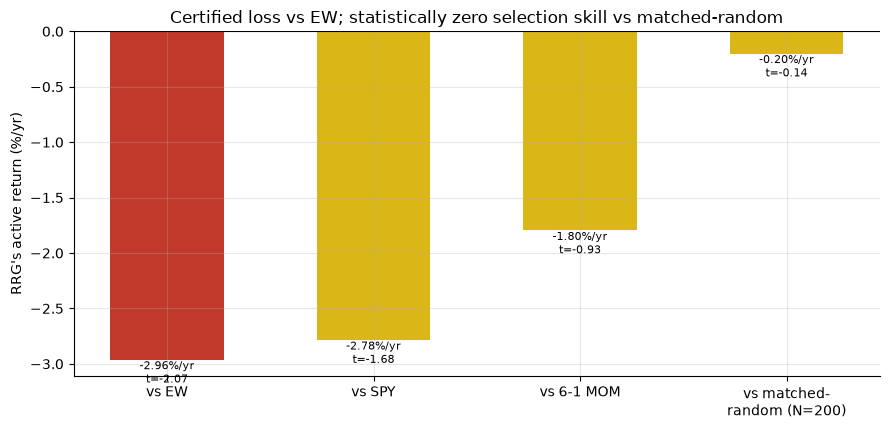

active: {'EW': (-2.9617380871277263, -2.0654442859863744), 'SPY': (-2.7846865556898748, -1.6797933882818261), 'MOM': (-1.7961521389517934, -0.927975900900598), 'RAND': (-0.19999124209792032, -0.14088459839824646)}


In [3]:
if HAVE_REAL:
    ctrl = st.matched_random_control(QUAD, RETS, n_seeds=50, cost_bps=R['cost_bps'])
    a_rand = st.active_stats(rrg['r_net'], ctrl)
    a_ew = st.active_stats(rrg['r_net'], ew)
    a_spy = st.active_stats(rrg['r_net'], spy_m)
    a_mom = st.active_stats(rrg['r_net'], mom['r_net'])
    acts = [a_ew['active_ann']*100, a_spy['active_ann']*100, a_mom['active_ann']*100, a_rand['active_ann']*100]
    act_ts = [a_ew['active_tstat'], a_spy['active_tstat'], a_mom['active_tstat'], a_rand['active_tstat']]
else:
    acts = [R['act_ew']['ann'], R['act_spy']['ann'], R['act_mom']['ann'], R['act_rand']['ann']]
    act_ts = [R['act_ew']['t'], R['act_spy']['t'], R['act_mom']['t'], R['act_rand']['t']]
labels = ['vs EW', 'vs SPY', 'vs 6-1 MOM', 'vs matched-\nrandom (N=200)']
fig, ax = plt.subplots(figsize=(9.0, 4.4))
cols = [RED if abs(t) >= 2 else AMBER for t in act_ts]
ax.bar(labels, acts, color=cols, width=.55)
for i, (v, t) in enumerate(zip(acts, act_ts)):
    ax.annotate(f'{v:+.2f}%/yr\nt={t:+.2f}', (i, v), ha='center',
        va='top' if v < 0 else 'bottom', fontsize=8)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel("RRG's active return (%/yr)")
ax.set_title('Certified loss vs EW; statistically zero selection skill vs matched-random')
plt.tight_layout(); plt.show()
print('active:', dict(zip(['EW','SPY','MOM','RAND'], zip(acts, act_ts))))

> 💡 In plain words: the matched-random control is the fair fight, and RRG loses it too (*t* = -0.35, -0.50%/yr) — statistically zero, meaning the Leading-quadrant *label* carries no information about which sector actually outperforms next month. The certified loss vs EW (*t* = -2.07) is a **design artifact**: RRG sat in cash 8% of months while EW stayed fully invested through a bull-tilted quarter-century.

### 4c · Cost sweep — turnover this high is not free

Mean one-way monthly turnover: **76.9%**.

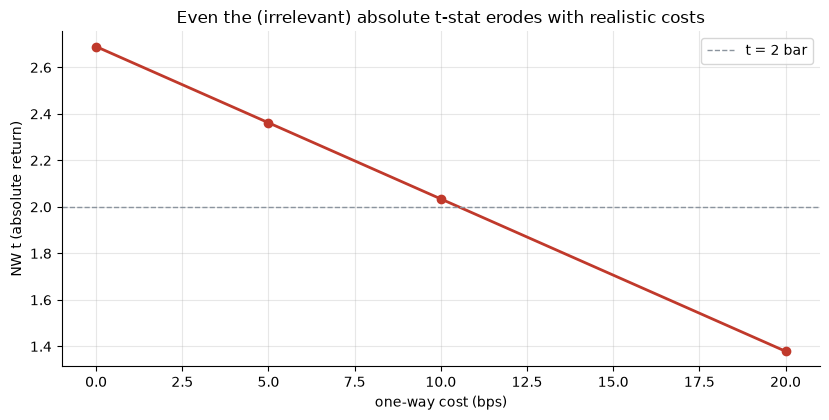

[(0.0, 7.58, 0.46, 2.69), (5.0, 6.66, 0.404, 2.36), (10.0, 5.74, 0.348, 2.03), (20.0, 3.89, 0.236, 1.38)]


In [4]:
if HAVE_REAL:
    cbs = [0.0, 5.0, 10.0, 20.0]
    anns_c, shs_c, ts_c = [], [], []
    for cb in cbs:
        r = st.run_rrg_strategy(QUAD, RETS, cost_bps=cb)
        s = st.summarize(r['r_net'])
        anns_c.append(s['ann_ret']*100); shs_c.append(s['sharpe']); ts_c.append(s['tstat'])
else:
    cbs = sorted(R['cost_sweep'])
    anns_c = [R['cost_sweep'][c][0] for c in cbs]
    shs_c = [R['cost_sweep'][c][1] for c in cbs]
    ts_c = [R['cost_sweep'][c][2] for c in cbs]
fig, ax = plt.subplots(figsize=(8.4, 4.3))
ax.plot(cbs, ts_c, 'o-', color=RED, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = 2 bar')
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('NW t (absolute return)')
ax.set_title('Even the (irrelevant) absolute t-stat erodes with realistic costs')
ax.legend(); plt.tight_layout(); plt.show()
print(list(zip(cbs, [round(a,2) for a in anns_c], [round(s,3) for s in shs_c], [round(t,2) for t in ts_c])))

### 4d · Sub-period stability — no era in which RRG beats equal-weight

Split at the two natural sector-ETF-liquidity eras (same split points as sibling 225).

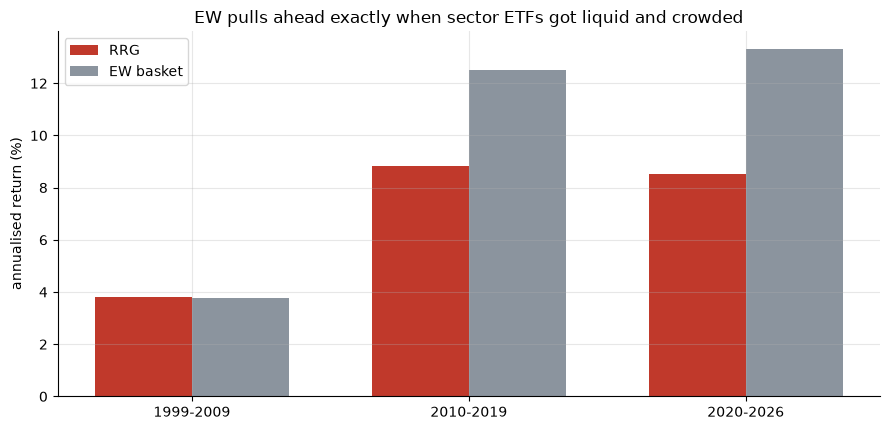

RRG: [3.814336615822686, 8.820596519510136, 8.52422418635022]  EW: [3.7709417373261083, 12.514341487355654, 13.32365995240275]


In [5]:
labels3 = list(R['sub_periods'].keys())
if HAVE_REAL:
    ranges = {'1999-2009': ('1999-07', '2009-12'), '2010-2019': ('2010-01', '2019-12'),
              '2020-2026': ('2020-01', '2026-06')}
    rrg_a, ew_a = [], []
    for lo, hi in ranges.values():
        m_r = (rrg.index >= lo) & (rrg.index <= hi)
        m_e = (ew.index >= lo) & (ew.index <= hi)
        rrg_a.append(st.summarize(rrg.loc[m_r, 'r_net'])['ann_ret'] * 100)
        ew_a.append(st.summarize(ew.loc[m_e])['ann_ret'] * 100)
else:
    rrg_a = [R['sub_periods'][k]['rrg_ann'] for k in labels3]
    ew_a = [R['sub_periods'][k]['ew_ann'] for k in labels3]
x = np.arange(len(labels3)); w = 0.35
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(x - w/2, rrg_a, w, label='RRG', color=RED)
ax.bar(x + w/2, ew_a, w, label='EW basket', color=GREY)
ax.set_xticks(x); ax.set_xticklabels(labels3)
ax.set_ylabel('annualised return (%)')
ax.set_title('EW pulls ahead exactly when sector ETFs got liquid and crowded')
ax.legend(); plt.tight_layout(); plt.show()
print('RRG:', rrg_a, ' EW:', ew_a)

### 4e · The myth-check — the full transition matrix

Pooled month-to-month quadrant transitions, all 11 tickers, 1999→2026.

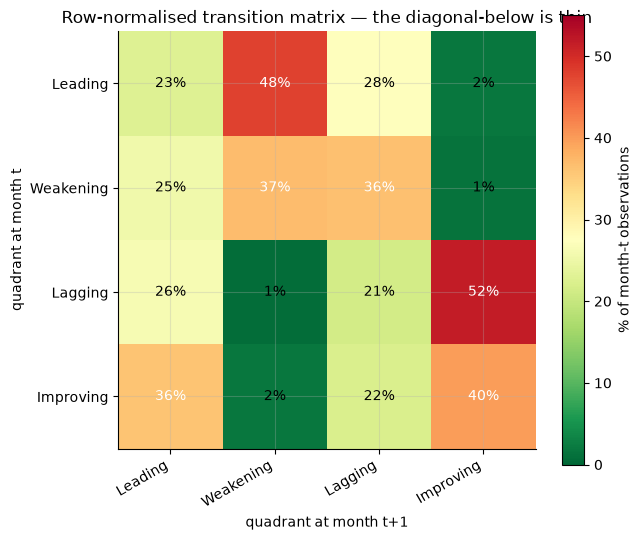

In [6]:
labels4 = ['Leading', 'Weakening', 'Lagging', 'Improving']
if HAVE_REAL:
    trans_df = st.quadrant_transition_matrix(QUAD)
    mat = trans_df.div(trans_df.sum(axis=1), axis=0).to_numpy() * 100
else:
    mat = np.array([[R['trans'][a][b] for b in labels4] for a in labels4], dtype=float)
    mat = mat / mat.sum(axis=1, keepdims=True) * 100
fig, ax = plt.subplots(figsize=(6.6, 5.6))
im = ax.imshow(mat, cmap='RdYlGn_r', vmin=0, vmax=55)
ax.set_xticks(range(4)); ax.set_xticklabels(labels4, rotation=30, ha='right')
ax.set_yticks(range(4)); ax.set_yticklabels(labels4)
ax.set_xlabel('quadrant at month t+1'); ax.set_ylabel('quadrant at month t')
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{mat[i,j]:.0f}%', ha='center', va='center', fontsize=10,
                color='white' if mat[i,j] > 30 else 'black')
ax.set_title('Row-normalised transition matrix — the diagonal-below is thin')
plt.colorbar(im, ax=ax, label='% of month-t observations')
plt.tight_layout(); plt.show()

> 💡 In plain words: pooled clockwise share of quadrant CHANGES = **61.7%** vs a **33.3%** random baseline (3 equally-likely destinations). Immediate reversals — Leading→Improving, Weakening→Improving, Lagging→Weakening — are all under 2%, because RS-Momentum is *defined* as the smoothed rate-of-change of RS-Ratio, so a orderly progression is partly baked into the construction. The one notable exception, Weakening→Leading (25.4%), shows the loop isn't perfectly clean either. **Descriptive**, not predictive — H₁ holds, H₂ still fails.

### 4f · Faithful-engine & power control — we know the truth here

Synthetic daily multi-sector panel, AR(1) persistent relative-drift knob (`mom_strength`), tested against the SAME matched-random control as the real tape. Null checked over 20 seeds — never a single stream.

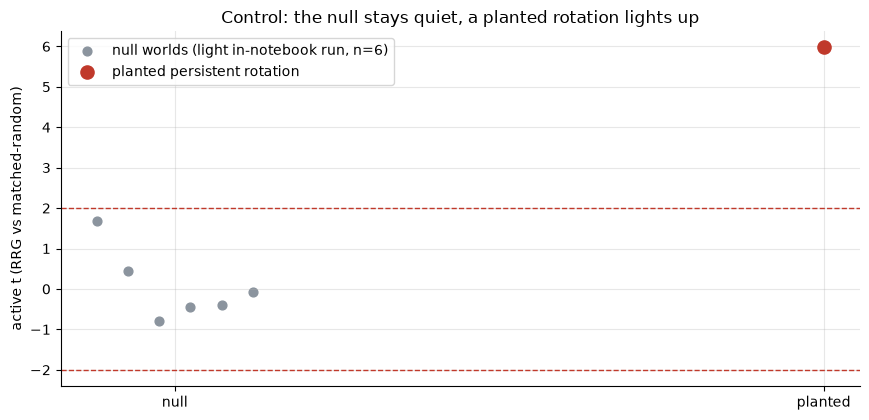

light null: mean t = +0.07 (sd 0.89)  |  planted t = +5.97
canonical (results.md, 20 seeds): mean t = -0.30 (sd 1.11), |t|>=2 in 1/20 seeds  |  planted t = +6.20


In [7]:
sec_cols = [f'SEC{i:02d}' for i in range(9)]
null_ts = []
for s_ in range(6):  # lighter in-notebook run; canonical 20-seed number in R
    p, _t = data.synthetic_panel(n_days=4000, n_sectors=9, mom_strength=0.0, seed=681 + s_)
    r = st.synthetic_detect(p, sec_cols, 'BENCH', data.RS_WINDOW, data.MOM_WINDOW, n_control_seeds=20)
    null_ts.append(r['active_tstat'])
null_ts = np.asarray(null_ts)
p, _t = data.synthetic_panel(n_days=6300, n_sectors=9, mom_strength=0.0015, seed=681)
planted = st.synthetic_detect(p, sec_cols, 'BENCH', data.RS_WINDOW, data.MOM_WINDOW, n_control_seeds=20)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(len(null_ts)) + np.linspace(-.12, .12, len(null_ts)), null_ts,
           color=GREY, s=40, label=f'null worlds (light in-notebook run, n={len(null_ts)})')
ax.scatter([1], [planted['active_tstat']], color=RED, s=90, zorder=5,
           label='planted persistent rotation')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null', 'planted'])
ax.set_ylabel('active t (RRG vs matched-random)')
ax.set_title('Control: the null stays quiet, a planted rotation lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'light null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f})  |  '
      f"planted t = {planted['active_tstat']:+.2f}")
print(f"canonical (results.md, 20 seeds): mean t = {R['syn_null_mean']:+.2f} "
      f"(sd {R['syn_null_sd']:.2f}), |t|>=2 in {R['syn_null_fire']}/{R['syn_null_seeds']} seeds  |  "
      f"planted t = {R['syn_planted_t']:+.2f}")

> 💡 In plain words: canonical 20-seed run (frozen in `results.md`) — null mean *t* = -0.30 (sd 1.11), \|t\| ≥ 2 in 1/20 seeds (≈ the false-positive rate the *t* ≥ 2 threshold implies on its own — not systematic over-firing); a planted persistent relative drift lights up at *t* = +6.20. The harness is powered to detect real rotation if it existed. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — vs the matched-random control (the fair test): *t* = -0.35 (-0.50%/yr), statistically zero selection skill. Doesn't beat plain 6-1 momentum (*t* = -0.93, negative point estimate). Underperforms equal-weight by a **certified** margin (*t* = -2.07) — a design artifact of the cash-timing rule, not evidence of anti-skill, but not an edge either.
- **Tradability `MIRAGE`** — 77% one-way monthly turnover, lowest Sharpe of four books (0.404), certified shortfall vs equal-weight in the 2010s and 2020s, costs erode even the (irrelevant) absolute significance.
- **Rotates clockwise? `CONFIRMED`** — 61.7% of quadrant changes go the claimed clockwise way vs a 33.3% random baseline. The chart's own story about *how* sectors move is descriptively true; it just isn't predictive of *which* one to buy.

## 6 · Going further

- **The construction is ours, not the vendor's.** StockCharts/Bloomberg don't publish their exact smoothing constants; a reader with access to the proprietary feed could re-run this exact protocol (same controls, same matched-random test, same synthetic power check) against the commercial series.
- **The natural next test** is whether the RRG adds anything at the *individual-stock* level (its more common professional use — rotating within an industry, not across the whole market) rather than across only 11 broad sectors.
- **Dedup map:** [225-sector-rotation](../../225-sector-rotation/) (the plain 1-D control used here, same universe, independently reaches "weak/mirage"), [506-industry-momentum](../../506-industry-momentum/) (long-short industry momentum on the same 11 ETFs, also a coin flip), [246-defensive-sectors](../../246-defensive-sectors/) (a two-sector risk-off timing canary — a different question, market-timing, not sector selection).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*